# Debug unstable learning

CPU companion; no accelerator is required. TPU execution not validated.

- Derive the gradient and curvature on paper
- Record pre-update and post-update quantities distinctly
- Use gradient clipping for a bounded symptom, not a diagnosis
- Change the feature scale and predict the new bound

The loss is growing. Should you immediately lower the learning rate? Let’s first gather evidence. We’ll use a one-weight model whose update we can derive, deliberately make it unstable, and inspect its losses, gradients and weights. You’ll learn how to connect a symptom to a cause.

## The idea

Unstable learning is a symptom with several possible causes. Connect the first unexpected value to inputs, forward computation, loss, gradients, optimizer state or the applied update. That ordering turns a vague failure into a testable diagnosis.

## Locate the first broken boundary

Start with a reproducible failing batch. Check inputs and forward loss before differentiating. If the loss is finite but gradients are not, inspect derivative-sensitive operations. If gradients are finite but the next loss explodes, inspect update size and parameter change.

Change one factor at a time and keep the original failing case. Clipping can limit damage without repairing the cause, so test whether the intervention predicts behavior on a changed input or learning rate.

The loss curve shows when behavior diverges. To explain why, add the relevant evidence: gradient norm, parameter norm, update norm and the first nonfinite intermediate. Keep those quantities distinct; a large parameter norm does not automatically imply a large gradient.

### Pause and reason

Why is “the loss is NaN” not yet a diagnosis?

<details><summary>Compare your reasoning</summary>

It names the final symptom. Find the earliest nonfinite value and its producing operation, then test a specific repair against the same failing case.

</details>

## Derive the gradient and curvature on paper

The training pairs are $x=[1, 2, 3]$ and $y=2x$. The head predicts $wx$, so the mean squared loss is $\operatorname{mean}(x^2)(w-2)^2=\frac{14}{3}(w-2)^2$. The gradient is $\frac{28}{3}(w-2)$, and the constant curvature is $28/3$. Gradient descent transforms the weight error $e=w-2$ into $(1-\eta\,28/3)e$. Stability requires the magnitude of that multiplier to be less than one, hence $0<\eta<\frac{3}{14}$ for this specific objective. This calculation lets us predict failure before observing a plot.

$$
\begin{aligned}L(w)&=\frac{14}{3}(w-2)^2\\e_{\mathrm{next}}&=\left(1-\eta\frac{28}{3}\right)e\\0&<\eta<\frac{3}{14}\approx0.214286\end{aligned}
$$

## Record pre-update and post-update quantities distinctly

At each iteration, record the current weight, loss, and absolute gradient, then compute the new weight. The history therefore describes the parameter entering each update. At rate $0.1$ the error multiplier is about $0.066667$; the weight converges quickly. At rate $0.3$ the multiplier is $-1.8$; errors alternate sign and grow in magnitude, with loss increasing by a factor $3.24$ per update until precision limits intervene. We run only six unstable steps to preserve a readable finite trace. A finite-number check catches overflow, but finite values can still represent a badly diverging run.

## Use gradient clipping for a bounded symptom, not a diagnosis

Clipping a scalar gradient to magnitude one limits each rate-0.3 update to at most $0.3$. That prevents the explosive trajectory in this small example, but it does not establish a generally correct learning rate, good final accuracy, or a solved numerical problem. Inspect the original norm as well as the clipped update. A repeatedly clipped run may indicate badly scaled features or excessive rate. Diagnose the data and objective before adopting clipping as a permanent fix. For cross-entropy models, large steps can produce confidently wrong finite predictions; monitoring only NaNs would miss them.

## Change the feature scale and predict the new bound

Multiply every $x$ and $y$ by ten while keeping the true weight two. The loss and curvature multiply by $100$, and the stable learning-rate ceiling divides by $100$. A rate of $0.1$ that was stable on the original data is now unstable. This demonstrates why a copied learning rate can fail after preprocessing changes. Standardization, objective normalization, adaptive optimizers, and clipping affect update behavior in different ways. Preserve an independent analytic check when possible, then instrument real networks with finite checks, gradient norms, prediction ranges, class balance, and evaluation isolation. Do not apply the quadratic bound to an unrelated model.

## 1. Define the controlled objective

Create main.py. Calculate $\operatorname{mean}(x^2)$ and the gradient at $w=0$ before running this block.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
x=jnp.array([1.,2.,3.]);y=2*x
def loss(w,features=x,targets=y):return jnp.mean((w*features-targets)**2)
def analytic_gradient(w):return (28/3)*(w-2)
np.testing.assert_allclose(loss(0.),56/3,rtol=1e-6)
np.testing.assert_allclose(jax.grad(loss)(0.),-56/3,rtol=1e-6)

The initial loss is $56/3$ and the initial gradient is $-56/3$. These values independently anchor the autodiff trace.

## 2. Instrument the update loop

Append the runner. Each history row stores pre-update weight, loss, and gradient magnitude; no optimizer library hides the update.

In [2]:
def run(rate,steps,features=x,targets=y,clip=None):
    w=jnp.array(0.);history=[]
    objective=lambda value:loss(value,features,targets)
    for _ in range(steps):
        value,grad=jax.value_and_grad(objective)(w)
        history.append([float(w),float(value),float(jnp.abs(grad))])
        assert np.all(np.isfinite(history[-1]))
        update=jnp.clip(grad,-clip,clip) if clip is not None else grad
        w=w-rate*update
    return float(w),np.asarray(history)
stable,good=run(.1,6)
unstable,bad=run(.3,6)
assert abs(stable-2)<1e-5 and bad[-1,1]>bad[0,1]*100

The rate changes while initial state, data, and objective stay fixed. This isolates the intervention.

## 3. Match the recorded failure to the exact recurrence

Append analytic comparisons for every recorded iteration, then print the finite divergence trace.

In [3]:
for rate,history in [(.1,good),(.3,bad)]:
    expected_w=2-2*(1-rate*28/3)**np.arange(len(history))
    expected_loss=(14/3)*(expected_w-2)**2
    np.testing.assert_allclose(history[:,0],expected_w,rtol=2e-5,atol=1e-5)
    np.testing.assert_allclose(history[:,1],expected_loss,rtol=2e-5,atol=1e-8)
np.testing.assert_allclose(bad[1:,1]/bad[:-1,1],3.24,rtol=1e-5)
print('Stable final weight:',stable,'unstable pre-update [weight,loss,|gradient|]:\n',bad)

Stable final weight: 1.999999761581421 unstable pre-update [weight,loss,|gradient|]:
 [[ 0.00000000e+00  1.86666679e+01  1.86666679e+01]
 [ 5.60000038e+00  6.04800110e+01  3.36000061e+01]
 [-4.48000145e+00  1.95955292e+02  6.04800148e+01]
 [ 1.36640034e+01  6.34895264e+02  1.08864037e+02]
 [-1.89952106e+01  2.05706152e+03  1.95955322e+02]
 [ 3.97913895e+01  6.66488281e+03  3.52719635e+02]]


An alternating parameter error and a $3.24$ loss multiplier support the learning-rate diagnosis. Near zero, float32 cancellation makes relative loss error misleading, so the analytic comparison uses a $10^{-8}$ absolute floor. No timing or accelerator result is claimed.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
x=jnp.array([1.,2.,3.]);y=2*x
def loss(w,features=x,targets=y):return jnp.mean((w*features-targets)**2)
def analytic_gradient(w):return (28/3)*(w-2)
np.testing.assert_allclose(loss(0.),56/3,rtol=1e-6)
np.testing.assert_allclose(jax.grad(loss)(0.),-56/3,rtol=1e-6)

def run(rate,steps,features=x,targets=y,clip=None):
    w=jnp.array(0.);history=[]
    objective=lambda value:loss(value,features,targets)
    for _ in range(steps):
        value,grad=jax.value_and_grad(objective)(w)
        history.append([float(w),float(value),float(jnp.abs(grad))])
        assert np.all(np.isfinite(history[-1]))
        update=jnp.clip(grad,-clip,clip) if clip is not None else grad
        w=w-rate*update
    return float(w),np.asarray(history)
stable,good=run(.1,6)
unstable,bad=run(.3,6)
assert abs(stable-2)<1e-5 and bad[-1,1]>bad[0,1]*100

for rate,history in [(.1,good),(.3,bad)]:
    expected_w=2-2*(1-rate*28/3)**np.arange(len(history))
    expected_loss=(14/3)*(expected_w-2)**2
    np.testing.assert_allclose(history[:,0],expected_w,rtol=2e-5,atol=1e-5)
    np.testing.assert_allclose(history[:,1],expected_loss,rtol=2e-5,atol=1e-8)
np.testing.assert_allclose(bad[1:,1]/bad[:-1,1],3.24,rtol=1e-5)
print('Stable final weight:',stable,'unstable pre-update [weight,loss,|gradient|]:\n',bad)

Stable final weight: 1.999999761581421 unstable pre-update [weight,loss,|gradient|]:
 [[ 0.00000000e+00  1.86666679e+01  1.86666679e+01]
 [ 5.60000038e+00  6.04800110e+01  3.36000061e+01]
 [-4.48000145e+00  1.95955292e+02  6.04800148e+01]
 [ 1.36640034e+01  6.34895264e+02  1.08864037e+02]
 [-1.89952106e+01  2.05706152e+03  1.95955322e+02]
 [ 3.97913895e+01  6.66488281e+03  3.52719635e+02]]


Expected: Rate $0.1$ approaches weight $2$. Rate $0.3$ produces alternating growing errors; consecutive unstable losses have ratio $3.24$ before overflow.

## Correct gradients can still produce unstable training

Predict: Which learning rate crosses the stability limit?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data = {'kind': 'line', 'x': list(range(len(good))), 'xlabel': 'pre-update step', 'ylabel': 'mean squared loss', 'yscale': 'log', 'series': [{'label': 'rate 0.1', 'y': good[:, 1].tolist()}, {'label': 'rate 0.3', 'y': bad[:, 1].tolist()}]}

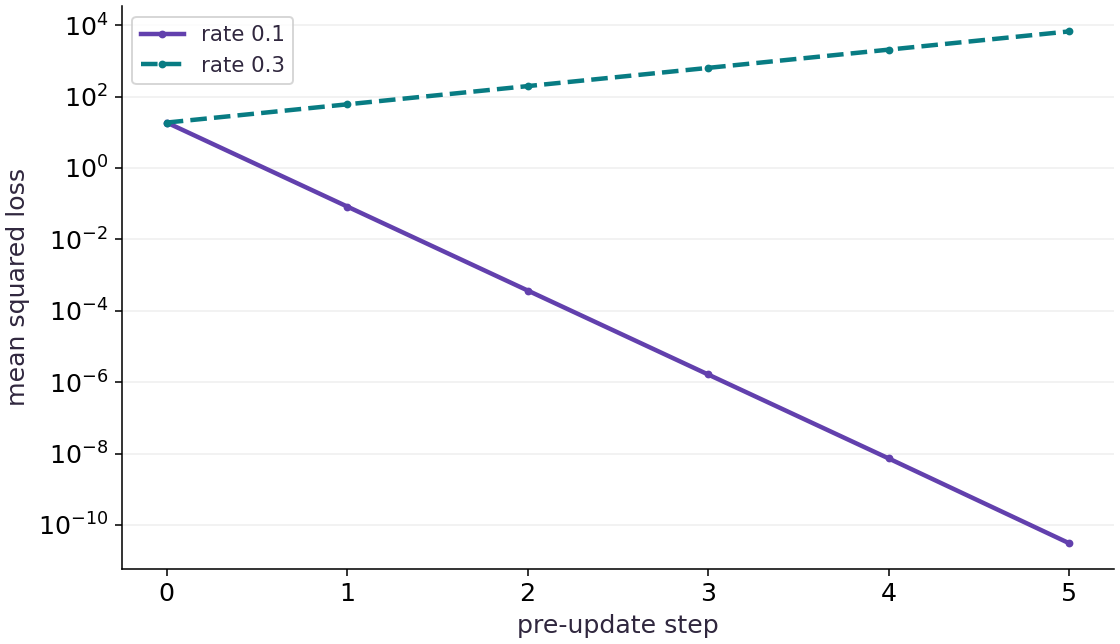

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis is the pre-update step: step $0$ shows the initial loss before training. The vertical axis is mean squared loss on a logarithmic scale. Both runs start at approximately $18.67$, but the solid rate-$0.1$ curve falls while the dashed rate-$0.3$ curve rises.

After the first update, the smaller rate gives loss about $0.083$, whereas the larger rate gives about $60.48$. By the last plotted step, the losses differ by many orders of magnitude. Equal vertical distances represent equal ratios, not equal absolute changes.

### Connect it to the computation

The loss here has curvature $28/3$. A step multiplies the weight error by $1-\eta(28/3)$. At rate $0.1$, this factor is $1/15$; at rate $0.3$, it is $-1.8$. The larger rate crosses the optimum and increases the error’s magnitude, so squared loss grows by a factor of $3.24$ per update.

The derivative can be correct while the update is unstable. That is the diagnosis this comparison isolates: change the step size before assuming a rising loss proves broken autodiff. The loss curve itself hides the sign alternation; the update equation explains it.

## Bounded clipped updates

Predict: At rate $0.3$ with clipping threshold one, how far can one scalar update move?

In [7]:
clipped,clipped_history=run(.3,6,clip=1.)
assert np.all(np.abs(np.diff(clipped_history[:,0]))<=.300001)
assert clipped_history[-1,1]<clipped_history[0,1]
assert clipped_history[0,2]>1.

Expected: Each recorded displacement is at most $0.3$ while the original gradient norm initially exceeds one.

Clipping changes the effective update. Its boundedness is a useful invariant, not proof of optimal training.

## Feature scaling changes curvature

Predict: Scale both features and targets by ten. Does the original stable rate remain stable?

In [8]:
scaled_final,scaled=run(.1,3,x*10,y*10)
assert scaled[-1,1]>scaled[0,1]
adjusted_final,adjusted=run(.001,6,x*10,y*10)
np.testing.assert_allclose(adjusted[:,0],good[:,0],rtol=1e-5,atol=1e-5)
np.testing.assert_allclose(adjusted[:,1],good[:,1]*100,rtol=1e-4,atol=1e-8)

Expected: Rate $0.1$ diverges after scaling. Dividing the rate by $100$ restores the original weight trajectory.

The gradient multiplies by $100$ because both prediction and target are scaled; adjusting rate compensates for this fixture.

## Your exercise

Use features $[1, 1, 1]$ and targets $2$. Predict the new stability ceiling. Compare stable rate $0.5$ and unstable rate $1.1$.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
ones=jnp.ones(3)
exact,history=run(.5,3,ones,2*ones)
divergent,divergent_history=run(1.1,6,ones,2*ones)
np.testing.assert_allclose(exact,2.,atol=1e-6)
assert divergent_history[-1,1]>divergent_history[0,1]
np.testing.assert_allclose(divergent_history[1:,1]/divergent_history[:-1,1],1.44,rtol=1e-5)

## Rescale the objective and compensate the update · Transfer

Multiply the squared-loss objective by five. Compare one plain gradient-descent update at the old rate and at one fifth of that rate. Explain why this compensation does not automatically describe Adam or clipping.

Hint: Differentiate the scaled objective; plain gradient descent multiplies its gradient by the learning rate.

In [11]:
# Write your attempt here.

## Reference reasoning

Scaling the objective scales the gradient. For this plain update the inverse rate change cancels it exactly. Stateful normalization, clipping and regularization need their own analysis.

In [12]:
w0=jnp.array(.25)
base_gradient=jax.grad(loss)(w0)
scaled_gradient=jax.grad(lambda w:5*loss(w))(w0)
np.testing.assert_allclose(scaled_gradient,5*base_gradient,rtol=1e-6)
reference=w0-.1*base_gradient
compensated=w0-(.1/5)*scaled_gradient
uncompensated=w0-.1*scaled_gradient
np.testing.assert_allclose(compensated,reference,rtol=1e-6)
assert not np.isclose(uncompensated,reference)
print('Reference / compensated / unchanged-rate updates:',reference,compensated,uncompensated)

Reference / compensated / unchanged-rate updates: 1.8833334 1.8833332 8.416667


## Diagnose a nonfinite input before an update · Intermediate

Insert one NaN feature. Show that loss/gradient finite checks fail, then repair the source data and recheck the independent initial gradient.

Hint: Changing the learning rate cannot make a NaN observation valid.

In [13]:
# Write your attempt here.

## Reference reasoning

Nonfinite data is a different cause than excessive step size. Repair it at ingestion and validate the objective before taking another update.

In [14]:
corrupted=x.at[1].set(jnp.nan)
bad_value,bad_grad=jax.value_and_grad(lambda w:loss(w,corrupted,y))(0.)
assert not np.isfinite(float(bad_value)) and not np.isfinite(float(bad_grad))
repaired=jnp.array([1.,2.,3.])
repaired_value,repaired_grad=jax.value_and_grad(lambda w:loss(w,repaired,y))(0.)
np.testing.assert_allclose(repaired_grad,-56/3,rtol=1e-6)
assert np.isfinite(float(repaired_value))

## Checkpoint

Why does scaling both $x$ and $y$ by ten require a different stable step-size range?

1. The squared-loss curvature grows by $100$
2. Autodiff stops working on scaled inputs
3. The number of observations changes

## Diagnose

Start with finite input and loss checks, then inspect shape contracts and independent objective values. Record gradient norm, parameter norm, learning rate, and step index. Alternating growing errors can support a curvature diagnosis; NaNs from corrupted inputs require data repair. Preserve separate train and held-out metrics before declaring the fix successful.

## Evidence

Keep the analytic error recurrence, per-step weight/loss/gradient norm for rates 0.1 and 0.3, observed 3.24 loss multiplier, changed-scale comparison, clipping bound, and one repaired nonfinite-input case.

## Carry forward

- Derive the gradient and curvature on paper
- Record pre-update and post-update quantities distinctly
- Use gradient clipping for a bounded symptom, not a diagnosis
- Change the feature scale and predict the new bound

## Primary references

- [JAX numerical accuracy](https://docs.jax.dev/en/latest/faq.html#numerical-accuracy)
- [Optax clipping transformations](https://optax.readthedocs.io/en/latest/api/transformations.html#optax.clip_by_global_norm)